# 04 -- The products: every product on one page, run against run, the comparisons last

This workbook reads the transfer functions workbook 03 wrote and puts every product a site has on one page.
It reports what the products say about each other -- kind against kind, rate against rate, run against run --
and only then, in the last section, sets them beside a processing done outside this run.

Nothing here is estimated again and no product is altered. Every file is read through
`auslamp_proc.products.read_tf`, which applies two rules before a curve is used: the EDI empty-data value
1e32 is masked component by component, together with the no-information convention of a zero impedance
carrying an error of 1e9, so a fill never enters a median; and the periods are sorted and duplicates dropped
before any interpolation, because some writers emit them unsorted and interpolation on an unsorted grid is
silently wrong. The yx phase is folded into the first quadrant by +180 deg in
`auslamp_proc.products.rho_phase`, which is what every panel and table below reads.

The five kinds are the same words the earlier workbooks use, and each is one product of the same record:

| word | what it is | code key |
|---|---|---|
| single station | the site's own H and E | `single` |
| remote site | one other site's H as the reference | `remote` |
| fleet stack | a coherence-weighted mean of several sites' H | `stack` |
| observatory | an INTERMAGNET one-second record as the reference | `obs` |
| stack + observatory | the stack with the observatory as a member | `stack_obs` |

Four checks state their failure criterion in bold above the cell and print a verdict below it. A check that
scores zero items prints UNJUDGED and counts as a failure. A criterion that is met is reported FAILED and is
not revised afterwards.

The last section is a comparison and not a test of the truth. Two independent processings of the same field
are two measurements, neither an oracle; the section is a shape check, and a difference in level is a gain, a
dipole length or a frame before it is the earth. Every source outside this run declares the frame its tensors
are in -- geomagnetic, geographic or instrument -- in `surveys/<SURVEY>/survey.yaml`, and the workbook refuses
a source that declares none: a tensor drawn on our axes in an undeclared frame is a different object on the
same picture.

In [1]:
# ---- parameters: change these and re-run the workbook ----
SURVEY = "queensland_phase1"  # any folder under surveys/: queensland_phase2 | queensland_phase3 | victoria
SITES = "all"                 # "all" | "largest" (the register's largest group) | a group name | ["Q49", "Q50"]
RUNS = "latest"               # "latest" = the newest stamp of every run name | "all" | ["first", "short10"]
KINDS = "all"                 # "all" | a list of the code keys: ["single", "remote", "stack"]
RATES = "all"                 # "all" | [1] | [10]; both rates of a site sit on the same page
COMPARE = "all"               # "all" | a list of the survey.yaml source names | "none" draws no comparison
SHOW = None                   # None = the first chosen site; a site name shows that site's page inline
PER_PAGE = 6                  # sites a gallery page
WORK_ROOT = None              # None = survey.yaml work_root; every figure and table lands under it


In [2]:
# ---- the agreement rule: a change here changes which pairs are called agreement ----
PERIOD_RANGE = (1, 50000)     # the periods drawn and scored, in s
AGREE_RHO = 0.20              # two curves agree where the rho ratio is within this fraction of one
AGREE_PHASE_DEG = 5.0         # ... and the phase difference is within this many degrees
AGREE_BAND = (5, 200)         # the band the agreement rule is read over, in s
BANDS = [(5, 10), (10, 100), (100, 1000), (1000, 10000)]   # the decades every table reports, in s


## The run and the sites

Everything below reads `<work_root>/survey/runs.csv` and the run folders `<site>/<run>_<stamp>/` that workbook
03 wrote. The ledger is appended to, and a resumed run writes a second row per product, so
`auslamp_proc.products.ledger` reduces it to one row per site, run, stamp, kind and rate before anything is
counted. `RUNS = "latest"` keeps the newest stamp of every run name, so a 1 Hz run and a 10 Hz run under
different names are both read and a repeated run name is not counted twice.

In [3]:
import time
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display

# mt_metadata logs a warning per channel while an EDI is read, and this workbook reads several hundred
from loguru import logger as _loguru
_loguru.remove()

from auslamp_proc import agreement as AG, products as PR, survey as SV
from auslamp_proc.process import KIND_WORD
from auslamp_proc.figures import products as FIG

pd.set_option("display.width", 235)
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 600)

T0 = time.time()
sv = SV.load_survey(SURVEY)
if WORK_ROOT:
    sv.cfg["work_root"] = WORK_ROOT
WORK = Path(sv.cfg["work_root"])
OUT = WORK / "survey"
OUT.mkdir(parents=True, exist_ok=True)
WRITTEN = []

ASKED, WHY = SV.select_sites(sv, SITES, 0)
PROD = PR.find_products(sv, ASKED, runs=RUNS, kinds=KINDS, rates=RATES)
CHOSEN = [s for s in ASKED if s in set(PROD.site)]
NO_PRODUCT = [s for s in ASKED if s not in set(PROD.site)]
PAIRS = PR.choose_runs(PR.ledger(WORK), RUNS)
RUN_TAG = "-".join(sorted({name for name, _stamp in PAIRS})) or "none"
SHOW_SITE = SHOW or (CHOSEN[0] if CHOSEN else "")

def _dec(cell):
    try:
        return float(str(cell).strip())
    except ValueError:
        return None

DECLINATION = {r.site: _dec(r.declination_deg) for r in sv.sites.itertuples()}
DECLINATION = {k: v for k, v in DECLINATION.items() if v is not None and np.isfinite(v)}

_cache = {}
def read(path):
    """One TFData per file. A page, four tables and the gallery all ask for the same file."""
    if path not in _cache:
        _cache[path] = PR.read_tf(path)
    return _cache[path]

print("survey       %s" % sv.cfg["name"])
print("work root    %s" % WORK)
print("sites        %d of %d asked for carry a product (%s)" % (len(CHOSEN), len(ASKED), WHY))
print("             %s" % " ".join(CHOSEN))
if NO_PRODUCT:
    print("no product   %s -- run workbook 03 over them" % " ".join(NO_PRODUCT))
for name, stamp in PAIRS:
    n = int(((PROD.run == name) & (PROD.stamp == stamp)).sum())
    rates = sorted(set(PROD[PROD.run == name].rate_hz))
    print("run          %-9s %s  %3d product(s) at %s Hz over %d site(s)"
          % (name, stamp, n, ", ".join("%g" % r for r in rates),
             PROD[PROD.run == name].site.nunique()))
print("products     %d rows, %d on disk" % (len(PROD), int(PROD.on_disk.sum())))
print("periods      %g to %g s drawn and scored" % PERIOD_RANGE)
print("agreement    within %.0f %% in rho and %.1f deg in phase over %g-%g s"
      % (100 * AGREE_RHO, AGREE_PHASE_DEG, AGREE_BAND[0], AGREE_BAND[1]))


survey       queensland_phase1
work root    E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1
sites        23 of 23 asked for carry a product (every site in sites.csv)
             Q49 Q50 Q51 Q52N Q53N Q60N Q61N Q62N Q63 Q64N Q65 Q72N Q73 Q74N Q75 Q76ALT Q77N Q83 Q84 Q85N Q86N Q87 Q88N
run          first     20260916_1054  115 product(s) at 1 Hz over 23 site(s)
run          short10   20260916_1120   15 product(s) at 10 Hz over 5 site(s)
products     130 rows, 130 on disk
periods      1 to 50000 s drawn and scored
agreement    within 20 % in rho and 5.0 deg in phase over 5-200 s


## The products found

One row per product: where it came from, how many periods it carries, what it cost, and which reference it
was built on. The `remote` and `members` columns are the ledger's, so a stack names the sites it averaged and
the weight each carried.

**This check fails if any product named in runs.csv is missing from disk, does not read as a transfer function
with finite impedance at 5 or more periods, or carries unsorted or duplicated periods.** The three limbs are
independent of the ledger that names the products: the first opens the file, the second counts the finite
off-diagonal elements the reader is left with after the fill is masked, and the third compares the file's own
period order with the sorted one. The run folders are also walked for EDIs the ledger does not name, which is
the other half of the same question and is reported beside the verdict.

In [4]:
rows, missing, too_short, out_of_order = [], [], [], []
for r in PROD.itertuples():
    if not r.on_disk:
        missing.append("%s %s %g Hz: %s" % (r.site, r.kind, r.rate_hz, Path(r.path).name))
        continue
    try:
        tf = read(r.path)
    except Exception as exc:
        missing.append("%s %s %g Hz: unreadable, %s" % (r.site, r.kind, r.rate_hz, type(exc).__name__))
        continue
    finite = max(tf.meta["n_finite"]["xy"], tf.meta["n_finite"]["yx"])
    if finite < 5:
        too_short.append("%s %s %g Hz: %d finite period(s)" % (r.site, r.kind, r.rate_hz, finite))
    if not tf.meta["source_sorted"] or tf.meta["n_duplicate_periods"]:
        out_of_order.append("%s %s %g Hz: sorted %s, %d duplicate(s)"
                            % (r.site, r.kind, r.rate_hz, tf.meta["source_sorted"],
                               tf.meta["n_duplicate_periods"]))
    rows.append(dict(site=r.site, run=r.run, kind=r.kind, rate_hz=r.rate_hz, params=r.params,
                     periods=tf.meta["n_periods"], shortest_s=round(float(tf.period.min()), 2),
                     longest_s=round(float(tf.period.max()), 0), finite_xy=tf.meta["n_finite"]["xy"],
                     finite_yx=tf.meta["n_finite"]["yx"], tipper=tf.meta["has_tipper"],
                     seconds=r.seconds, rss_mb=r.peak_rss_mb, remote=r.remote,
                     members=(str(r.members)[:46] if r.members else "")))
found = pd.DataFrame(rows)
print(found.to_string(index=False))
print()
print("the reference kinds, as words and as the code keys the file names carry")
print(PR.kind_words().to_string(index=False))
print()
spare = PR.unledgered(WORK, CHOSEN, PAIRS)
print("%d EDI(s) sit in the chosen run folders without a ledger row%s"
      % (len(spare), (": " + "; ".join(Path(p).name for p in spare[:6])) if spare else ""))

n = len(PROD)
if not n:
    print("VERDICT: UNJUDGED -- runs.csv names no product for the chosen sites and runs")
elif missing or too_short or out_of_order:
    print("VERDICT: FAIL -- %d of %d products are missing or unreadable (%s); %d read fewer than 5 finite "
          "periods (%s); %d carry unsorted or duplicated periods (%s)"
          % (len(missing), n, "; ".join(missing[:4]) or "none", len(too_short),
             "; ".join(too_short[:4]) or "none", len(out_of_order), "; ".join(out_of_order[:4]) or "none"))
else:
    print("VERDICT: PASS -- all %d products named in runs.csv are on disk, each reads as a transfer function "
          "with %d to %d finite off-diagonal periods over %.2f to %.0f s, and every one carries its periods "
          "sorted and unique"
          % (n, int(found[["finite_xy", "finite_yx"]].max(axis=1).min()),
             int(found[["finite_xy", "finite_yx"]].max(axis=1).max()),
             float(found.shortest_s.min()), float(found.longest_s.max())))


  site     run      kind  rate_hz      params  periods  shortest_s  longest_s  finite_xy  finite_yx  tipper  seconds  rss_mb     remote                                        members
   Q49   first    single      1.0 kaiser20_75       48        2.30    48470.0         48         48    True    239.3  3522.9        NaN                                            nan
   Q49   first    remote      1.0 kaiser20_75       41        2.30    12118.0         41         41    True    324.1  3823.3 REMOTE_Q84                                        Q84:1.0
   Q49   first     stack      1.0 kaiser20_75       48        2.30    48470.0         47         47    True    311.4  4473.4      STACK Q73:0.9659;Q50:0.9647;Q60N:0.961;Q76ALT:0.9609
   Q49   first       obs      1.0 kaiser20_75       48        2.30    48470.0         47         47    True    329.5  4473.4    OBS_CTA                                     CTA:0.8698
   Q49   first stack_obs      1.0 kaiser20_75       48        2.30    48470.0        

## One site, every product

Every product of one site on one page: apparent resistivity and phase for xy and yx, and the tipper as real
parts in filled circles and imaginary parts as open triangles on a dotted line. The kind is the colour, the
rate is the line style (1 Hz solid, 10 Hz dashed) and the run is the marker, so the three questions the page
answers are readable at once. The y limits of the rho panels are the 2nd to 98th percentile of every curve
drawn, padded half a decade each way; the phase panels are fixed at 0-90 deg. The header lines under the
title are the product's own, taken from the EDI's processing_parameters.

What to look for. The single station sits below the referenced kinds wherever the site's own H noise is
coherent with itself, which is the short end at most sites. The remote-referenced kinds -- remote site, fleet
stack, observatory, stack + observatory -- should lie on each other at 100-1000 s, where the field is large
and every reference sees the same source; a kind that departs from the others there is the one to read, not
the average of them. The error bars grow at the long end, where the record runs out of independent windows.
The tipper's real and imaginary parts are drawn together because a real part alone cannot be told from a leak.

A page is written for every chosen site to `<work_root>/<site>/products_<run>.png`.

23 site page(s) written, one per chosen site
showing Q49


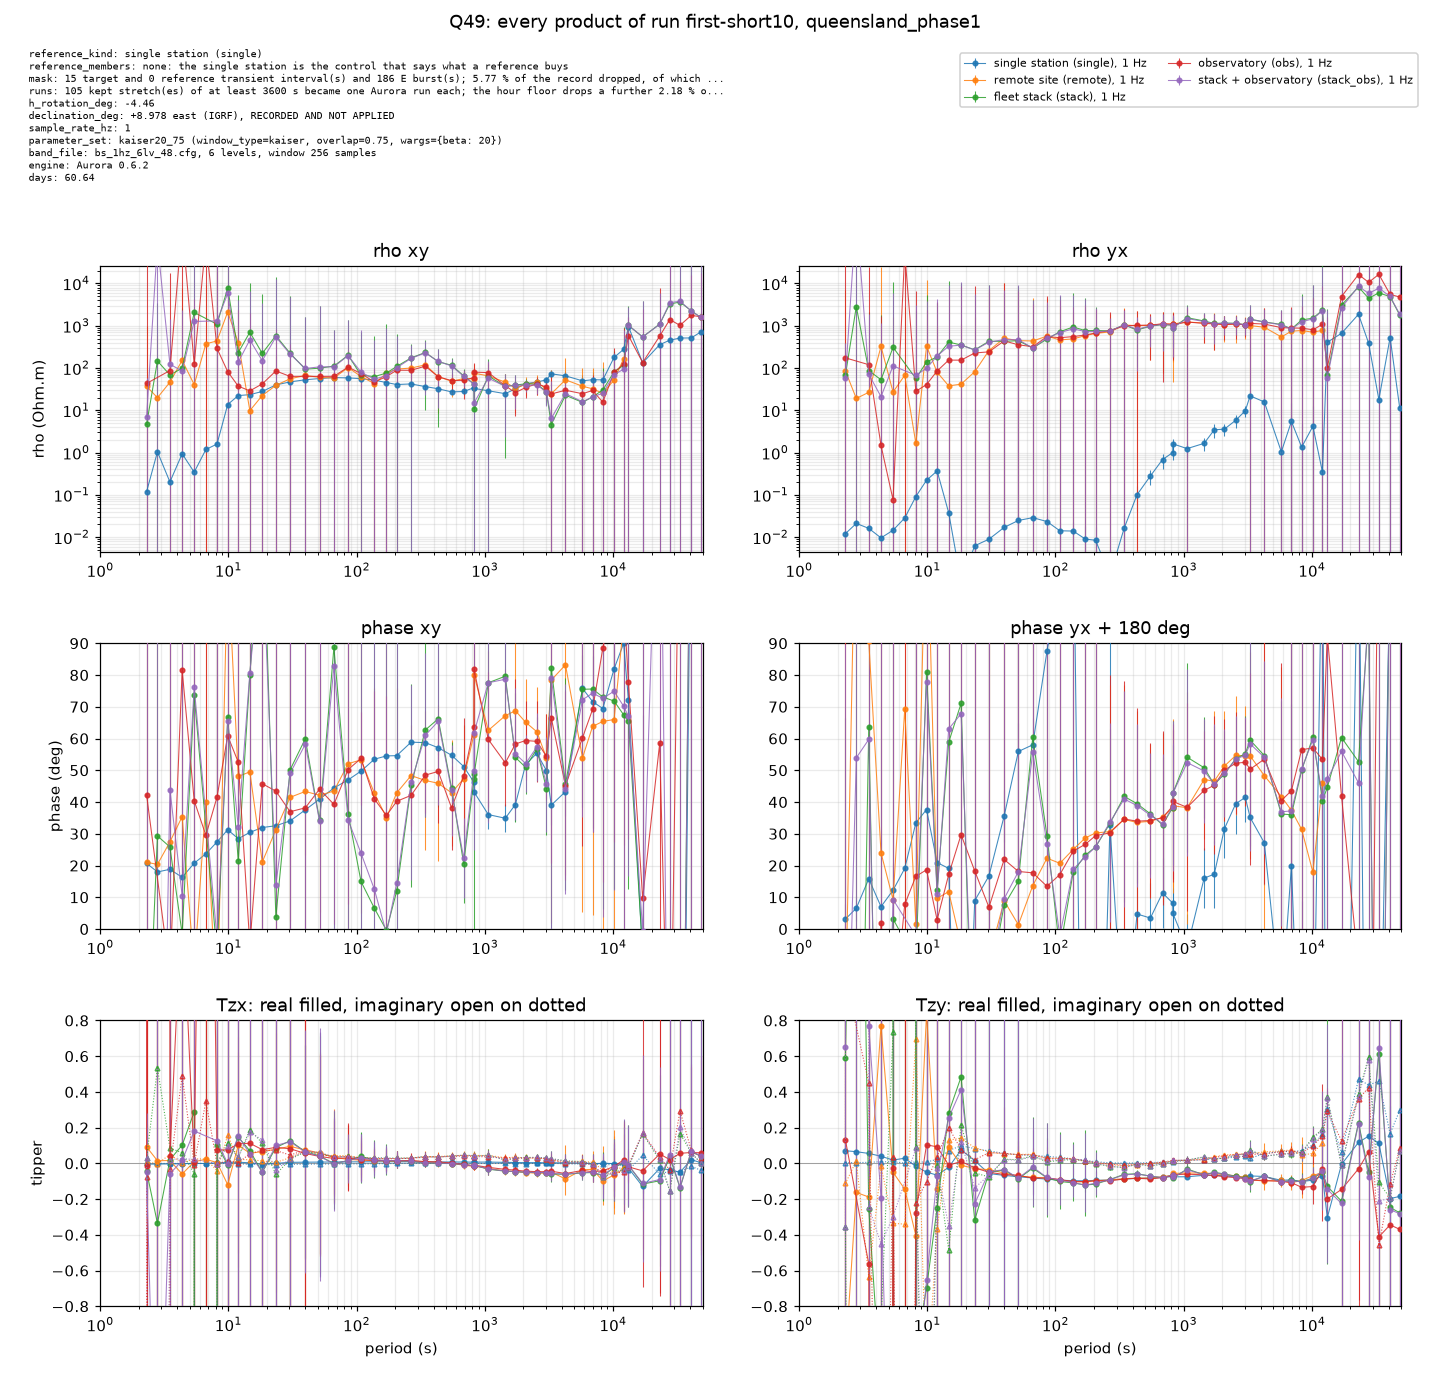

In [5]:
pages = []
for site in CHOSEN:
    grp = PROD[PROD.site == site]
    on = grp[grp.on_disk]
    head = PR.metadata_lines(read(on.iloc[0].path).meta) if len(on) else []
    path, _index = FIG.site_page(
        site, grp, read, WORK / site / ("products_%s.png" % RUN_TAG),
        title="%s: every product of run %s, %s" % (site, RUN_TAG, sv.cfg["name"]),
        header_lines=head, period_range=PERIOD_RANGE)
    pages.append(path)
WRITTEN += pages
print("%d site page(s) written, one per chosen site" % len(pages))
print("showing %s" % SHOW_SITE)
display(Image(filename=str(WORK / SHOW_SITE / ("products_%s.png" % RUN_TAG))))


## Kind against kind

For every site and rate, every pair of kinds is scored per decade: the median ratio of apparent resistivity
(the ratio of the squared impedance magnitudes) and the median phase difference in degrees, over the periods
both curves carry. `auslamp_proc.agreement.on_grid` puts the second curve on the first's periods by linear
interpolation in log period of log |Z| and of the unwrapped phase, with no extrapolation beyond the second
curve's own first and last valid node and no bridging of a hole wider than 0.30 decades.

The rule: two kinds agree where the rho ratio is within AGREE_RHO of one and the phase difference is within
AGREE_PHASE_DEG, both over AGREE_BAND. At the default values that is 20 per cent and 5 deg over 5-200 s.
Agreement between two references that share no magnetics is the evidence that neither is carrying its own
noise into the estimate; disagreement between them is not resolved here, and is workbook 06's question.

**This check fails if the table is UNJUDGED (no pair scored).** A site with one kind yields no pair, and a
survey where no pair could be put on a common period range scores nothing at all; either is a failure, because
a table of no rows cannot support the reading above it.

In [6]:
kk = AG.kind_vs_kind(PROD, read=read, bands=[tuple(b) for b in BANDS], agree_rho=AGREE_RHO,
                     agree_phase=AGREE_PHASE_DEG, agree_band=tuple(AGREE_BAND))
band_tag = AG.band_label(*AGREE_BAND)
scored = kk[(kk.band == band_tag) & (kk.n > 0)]
counts = []
for (site, rate), g in scored.groupby(["site", "rate_hz"]):
    pairs = g.groupby(["kind_a", "kind_b"]).agrees.all()
    counts.append(dict(site=site, rate_hz=rate, pairs=int(len(pairs)), agreeing=int(pairs.sum()),
                       worst_rho_ratio=round(float(g.rho_ratio.iloc[
                           int(np.nanargmax(np.abs(np.log(g.rho_ratio.values))))]), 3),
                       worst_phase_deg=round(float(g.phase_diff_deg.iloc[
                           int(np.nanargmax(np.abs(g.phase_diff_deg.values)))]), 2),
                       disagreeing=" ".join(sorted({"%s-%s" % k for k, v in pairs.items() if not v}))))
agree_counts = pd.DataFrame(counts)
print("both components inside %.0f %% and %.1f deg over %s; a pair counts as agreeing only where both do"
      % (100 * AGREE_RHO, AGREE_PHASE_DEG, band_tag))
print(agree_counts.to_string(index=False))
print()
print("the per-decade table, the first site as an example")
if len(CHOSEN):
    ex = kk[(kk.site == CHOSEN[0]) & (kk.band != band_tag)]
    print(ex[["kind_a", "kind_b", "rate_hz", "band", "component", "rho_ratio", "phase_diff_deg",
              "n"]].round(3).to_string(index=False))
path = OUT / ("agreement_kinds_%s.csv" % RUN_TAG)
kk.round(4).to_csv(path, index=False)
WRITTEN.append(path)
print()
print("-> %s (%d rows)" % (path, len(kk)))

if not len(scored):
    print("VERDICT: UNJUDGED -- no pair of kinds was scored over %s" % band_tag)
else:
    n_pairs = int(agree_counts.pairs.sum())
    n_agree = int(agree_counts.agreeing.sum())
    print("VERDICT: PASS -- %d pairs of kinds scored over %d site-rate(s); %d of them agree within %.0f %% "
          "and %.1f deg over %s and %d do not (%s)"
          % (n_pairs, len(agree_counts), n_agree, 100 * AGREE_RHO, AGREE_PHASE_DEG, band_tag,
             n_pairs - n_agree,
             " ".join(sorted({x for s in agree_counts.disagreeing for x in s.split() if x})) or "none"))


both components inside 20 % and 5.0 deg over 5-200 s; a pair counts as agreeing only where both do
  site  rate_hz  pairs  agreeing  worst_rho_ratio  worst_phase_deg                                                                                                  disagreeing
   Q49      1.0     10         2            0.000            31.55 obs-stack_obs remote-stack remote-stack_obs single-obs single-remote single-stack single-stack_obs stack-obs
   Q50      1.0     10        10            0.930            -0.53                                                                                                             
   Q51      1.0     10         6            0.000            13.89                                                       single-obs single-remote single-stack single-stack_obs
  Q52N      1.0     10         6            0.013            12.45                                                       single-obs single-remote single-stack single-stack_obs
  Q53N      1.0     1

## Rate against rate

Where a site carries both a 1 Hz and a 10 Hz product of the same kind, the two are compared on the bands each
side of the 16 s join: 8-16 s below and 32-100 s above, with 18-36 s left as a guard band because the Earth
Data logger writes an instrument line at 20.6 s. The number reported is the difference in apparent resistivity
as a percentage of the 1 Hz level, and the phase difference in degrees.

Aurora at 10 Hz reads about 8 per cent low at 4-32 s against its own 1 Hz product (AusLAMP Victoria,
2026-09-11), and every 10 Hz product carries that sentence in its own file. Nothing is spliced here; the join
is workbook 06's work, and this section is the measurement it will be decided on. A reading, not a check.

In [7]:
rows = []
for site in sorted(set(PROD.site)):
    g = PROD[(PROD.site == site) & PROD.on_disk]
    for kind in sorted(set(g.kind)):
        a = g[(g.kind == kind) & (g.rate_hz == 1.0)]
        b = g[(g.kind == kind) & (g.rate_hz == 10.0)]
        if not len(a) or not len(b):
            continue
        for _, r in AG.rate_step(read(a.iloc[0].path), read(b.iloc[0].path)).iterrows():
            rows.append(dict(site=site, kind=kind, component=r.component,
                             below_8_16_pct=round(r.below_pct, 1), below_phase_deg=round(r.below_phase_deg, 2),
                             above_32_100_pct=round(r.above_pct, 1),
                             above_phase_deg=round(r.above_phase_deg, 2),
                             n_below=int(r.n_below), n_above=int(r.n_above)))
steps = pd.DataFrame(rows)
if not len(steps):
    print("no site carries both a 1 Hz and a 10 Hz product of the same kind in this run; the rate step is "
          "not scored")
else:
    print("the 1 Hz level minus the 10 Hz level, as a per cent of the 1 Hz apparent resistivity")
    print(steps.to_string(index=False))
    print()
    print("median below the join %+.1f %%, above %+.1f %%; the 10 Hz product reads %s at 8-16 s"
          % (steps.below_8_16_pct.median(), steps.above_32_100_pct.median(),
             "low" if steps.below_8_16_pct.median() > 0 else "high"))
    ten = PROD[(PROD.rate_hz == 10.0) & PROD.on_disk]
    if len(ten):
        caveat = read(ten.iloc[0].path).meta["parameters"].get("caveat_10hz", "")
        print("the caveat every 10 Hz product carries: %s" % caveat)


the 1 Hz level minus the 10 Hz level, as a per cent of the 1 Hz apparent resistivity
site   kind component  below_8_16_pct  below_phase_deg  above_32_100_pct  above_phase_deg  n_below  n_above
Q60N remote        xy             2.9            -0.12               0.5             0.04        4        4
Q60N remote        yx             2.1            -0.27               0.3             0.03        4        4
Q60N single        xy           -35.0             0.10               0.5            -0.00        4        4
Q60N single        yx           -13.0            -0.44               1.3             0.01        4        4
Q60N  stack        xy             4.2            -0.18               0.5            -0.04        4        4
Q60N  stack        yx             2.4            -0.39               0.4             0.01        4        4
Q61N remote        xy             2.4            -0.33               0.5             0.00        4        4
Q61N remote        yx             2.0            -0

## Run against run

Where a site has the same kind and rate under two runs, the two are put on the ten-per-decade grid
T = 10^(k/10) from 3.16 s to 50,119 s, which belongs to neither of them, and the largest change per decade is
reported. Two runs of the same site and kind differ only in what the run itself did -- a mask, a window, a
reference the rule chose differently on the day -- so a change here is the size of that decision.

A site with one run yields nothing to compare, which is stated as a reading and not as a verdict: there is no
criterion a single run can fail.

In [8]:
rr = AG.run_vs_run(PROD, read=read, bands=[tuple(b) for b in BANDS])
if not len(rr):
    per_site = PROD.groupby(["site", "kind", "rate_hz"]).run.nunique()
    print("UNJUDGED: no site carries the same kind and rate under two runs -- %d site-kind-rate combination(s) "
          "each have one run, so there is nothing to compare across runs"
          % int((per_site == 1).sum()))
    print("the runs present: %s" % ", ".join("%s_%s" % p for p in PAIRS))
else:
    worst = (rr.assign(change=lambda d: np.abs(np.log(d.rho_ratio)))
               .sort_values("change", ascending=False)
               .groupby(["site", "kind", "rate_hz"]).head(1))
    print("the largest change per site, kind and rate, over the decades %s"
          % ", ".join(AG.band_label(*b) for b in BANDS))
    print(worst[["site", "kind", "rate_hz", "run_a", "run_b", "band", "component", "rho_ratio",
                 "phase_diff_deg", "n"]].round(3).to_string(index=False))


UNJUDGED: no site carries the same kind and rate under two runs -- 130 site-kind-rate combination(s) each have one run, so there is nothing to compare across runs
the runs present: first_20260916_1054, short10_20260916_1120


## Smoothness

A reading of each curve on its own, with no oracle and no other product. Each point of log rho and of the
phase is compared with a weighted quadratic fitted to its three neighbours each side, the point itself left
out, with the product's own error bars as the weights; the residual over the combined sigma is the score, and
a point above 4 is a jump. Curvature is absorbed by the quadratic, so a steep smooth curve scores nothing and
a single-period spike or a step at a decimation seam stands out. Reported beside it: the largest phase step
between adjacent periods in degrees, taken the short way round the circle so a curve crossing +-180 deg is not
read as a 360 deg step, the same step as a rate in degrees a decade with the spacing floored at 0.05 decades,
and the median residual against the local one-dimensional relation phi = 45 deg x (1 - d log rho / d log T),
which runs 10-15 deg at a two- or three-dimensional site and is read together with the jumps, never alone.

A jump count is a property of the bars as much as of the curve: a product with small bars and a real bend
scores jumps that a noisier product of the same earth does not.

In [9]:
rows = []
for r in PROD[PROD.on_disk].itertuples():
    for _, s in AG.smoothness(read(r.path), period_range=PERIOD_RANGE).iterrows():
        rows.append(dict(site=r.site, kind=r.kind, rate_hz=r.rate_hz, component=s.component,
                         periods=int(s.n_periods), jumps=int(s.n_jumps),
                         jumps_per_decade=s.jumps_per_decade,
                         phase_step_deg=round(float(s.max_phase_step_deg), 1),
                         phase_step_deg_per_decade=round(float(s.max_phase_step_deg_per_decade), 1),
                         median_abs_dphi_deg=round(float(s.median_abs_dphi_deg), 1)))
smooth = pd.DataFrame(rows)
by_product = (smooth.groupby(["site", "kind", "rate_hz"])
              .agg(jumps_per_decade=("jumps_per_decade", "mean"),
                   phase_step_deg=("phase_step_deg", "max"),
                   phase_step_per_decade=("phase_step_deg_per_decade", "max"),
                   dphi=("median_abs_dphi_deg", "median")).reset_index().round(2))
print("per kind, the mean over the %d product(s) of that kind" % len(PROD[PROD.on_disk]))
print(smooth.groupby("kind")[["jumps_per_decade", "phase_step_deg", "phase_step_deg_per_decade",
                              "median_abs_dphi_deg"]].mean().round(2).to_string())
print()
ranked = by_product.sort_values(["jumps_per_decade", "dphi"])   # <- the rho-phase residual breaks the ties
print("the five cleanest products by jumps per decade over %g-%g s, the rho-phase residual breaking ties"
      % PERIOD_RANGE)
print(ranked.head(5).to_string(index=False))
print()
print("the five roughest")
print(ranked.tail(5).to_string(index=False))


per kind, the mean over the 130 product(s) of that kind
           jumps_per_decade  phase_step_deg  phase_step_deg_per_decade  median_abs_dphi_deg
kind                                                                                       
obs                    0.58          133.08                    1599.45                30.11
remote                 1.55          104.48                    1201.03                23.13
single                 3.87           77.32                    1014.46                46.00
stack                  3.30          131.09                    1530.31                33.72
stack_obs              2.72          141.92                    1721.92                40.89

the five cleanest products by jumps per decade over 1-50000 s, the rho-phase residual breaking ties
site   kind  rate_hz  jumps_per_decade  phase_step_deg  phase_step_per_decade  dphi
Q52N    obs      1.0               0.0           154.0                 1761.8  4.60
 Q51 remote      1.0           

## The comparisons, last

This section sets our products beside a processing done outside this run. It comes last, and it is labelled a
comparison and never the truth, for one reason: two independent processings of the same field are two
measurements. Neither is an oracle. A difference in level is a gain, a dipole length or a frame before it is
the earth, and a difference that the declination turn removes was never a difference in the earth at all.

Every source is declared in `surveys/<SURVEY>/survey.yaml` with the frame its tensors are in and a note
saying what it is, and `auslamp_proc.products.comparison_sources` refuses one that declares neither:

| frame | what is done to the source |
|---|---|
| geomagnetic | compared as it is: the source is already in the mean-field frame ours are served in |
| geographic | turned into our frame by +declination_deg from sites.csv (Z' = R Z R^T, T' = T R^T, R = [[cos, sin], [-sin, cos]]), which is the inverse of the to_geographic_north_deg angle every product of ours carries |
| instrument | compared as laid, with the note printed beside the table |

The comparison is what moves; our products are never turned. A source declaring `rho_factor` -- a level its
own record says it is out by -- is multiplied by it in apparent resistivity, and the factor is stated in every
figure title and every table row it enters.

The reading per site, kind and component follows the same three explanations a difference can have: a SCALE
is a constant ratio with the phase untouched, which is a dipole length or a gain and is the only one a number
can fix; a FRAME is a disagreement the declination turn removes; a FAULT is neither -- the ratio wanders with
period, or the phase disagrees and the turn does not fix it. It is a reading and not a check.

**This check fails if a declared source lacks a frame declaration, or if the frame turn applied to any tensor
changes a rotation invariant by more than 1e-9 relative.** The second limb is an independent observable of the
turn itself: Zxy - Zyx, Zxx + Zyy and det Z are unchanged by Z' = R Z R^T for any rotation R, so a turn that
moves one of them is a scale, a reflection or an index slip and not a rotation. Each is compared with the
largest element of the same tensor at the same period, because a one-dimensional site has Zxx + Zyy = 0
exactly and a relative bound on zero is one no arithmetic can meet.

In [10]:
SOURCES = PR.comparison_sources(sv, COMPARE)
vs_tables, no_frame, turn_bad, turn_n = {}, [], [], 0
for src in SOURCES:
    print("source       %s" % src["name"])
    print("  folder     %s" % src["folder"])
    print("  frame      %s" % (src["frame"] or "NOT DECLARED"))
    print("  note       %s" % (src["note"] or "NOT DECLARED"))
    if src["rho_factor"] != 1.0:
        print("  rho_factor %.3f applied to the comparison, as survey.yaml declares" % src["rho_factor"])
    if src["error"]:
        no_frame.append("%s: %s" % (src["name"], src["error"]))
        print("  REFUSED    %s" % src["error"])
        print()
        continue
    tab = AG.versus_comparison(PROD, src, DECLINATION, read=read, bands=[tuple(b) for b in BANDS],
                               agree_rho=AGREE_RHO, agree_phase=AGREE_PHASE_DEG,
                               agree_band=tuple(AGREE_BAND))
    vs_tables[src["name"]] = tab
    for site in sorted(set(PROD.site)):
        dec = DECLINATION.get(site)
        if dec is None:
            continue
        for _kind, tf in PR.load_comparison(src, site, dec).items():
            turned = PR.turn_to_our_frame(tf, dec)
            ok = np.all(np.isfinite(tf.z.reshape(len(tf.period), -1)), axis=1)
            if not ok.any():
                continue
            scale = np.nanmax(np.abs(tf.z[ok]).reshape(int(ok.sum()), -1), axis=1)
            for label, f in (("Zxy - Zyx", lambda a: a[:, 0, 1] - a[:, 1, 0]),
                             ("Zxx + Zyy", lambda a: a[:, 0, 0] + a[:, 1, 1]),
                             ("det Z", lambda a: a[:, 0, 0] * a[:, 1, 1] - a[:, 0, 1] * a[:, 1, 0])):
                d = np.abs(f(turned.z[ok]) - f(tf.z[ok])) / np.maximum(scale ** (2 if label == "det Z" else 1),
                                                                       1e-30)
                turn_n += 1
                if np.nanmax(d) > 1e-9:
                    turn_bad.append("%s %s %s: %.2e" % (src["name"], site, label, float(np.nanmax(d))))
    hit = tab[(tab.band == AG.band_label(*AGREE_BAND)) & (tab.n > 0)]
    print("  scored     %d site(s), %d kind(s), %d row(s); %d of %d readings agree"
          % (tab.site.nunique(), tab.kind.nunique(), len(tab), int((hit.reading == "agrees").sum()), len(hit)))
    print()
print("%d tensor invariant(s) tested across %d source(s)" % (turn_n, len(vs_tables)))


source       earlier_processing
  folder     E:/MT_Timeseries_DATA/MT_AusLAMP_QLD/processed_2026/phase1_v1
  frame      geomagnetic
  note       Ben's September 2026 Aurora processing of Phase 1, single station and remote site, 1 Hz and 10 Hz; the same raw data through a different code path, rotated so each site's mean Hy is zero (processed_2026 README, Site setup and the coordinate frame)


  scored     5 site(s), 3 kind(s), 150 row(s); 24 of 30 readings agree

source       campaign_merged
  folder     E:/MT_Timeseries_DATA/MT_AusLAMP_QLD/processed_2026/final_2026-09-09/merged_edi
  frame      geomagnetic
  note       the September 2026 campaign's deliverable, one merged EDI per station (qld_merge_edis.py, 2026-09-09): a 1 Hz long file, a middle piece below 100 s where a clean window beat the whole record, and a 10 Hz short end below 20 s aligned onto the long file by a local level and phase factor, on a common grid of ten periods a decade; it is one curve per site and not one per reference kind, rows that are not products are blanked with the EDI 1e32 fill, and several sites stand on a stand-in H or a window rather than the whole record (MERGED_INDEX.csv names what each file is made of)


  scored     23 site(s), 5 kind(s), 1300 row(s); 170 of 250 readings agree

114 tensor invariant(s) tested across 2 source(s)


### What the comparison says, per site and kind

The table below is the 100-1000 s band: the median ratio of our apparent resistivity to the source's, the
median phase difference in degrees, and the reading. A ratio above one means our level is the higher of the
two. The source's frame and note are printed above; the numbers are a shape check.

In [11]:
for name, tab in vs_tables.items():
    src = [s for s in SOURCES if s["name"] == name][0]
    mid = tab[(tab.band == "100-1000 s") & (tab.n > 0)]
    if not len(mid):
        print("%s: nothing scored at 100-1000 s" % name)
        continue
    piv = mid.pivot_table(index=["site", "kind"], columns="component",
                          values=["rho_ratio", "phase_diff_deg"]).round(3)
    print("%s -- ours over the source at 100-1000 s, frame %s%s"
          % (name, src["frame"],
             "" if src["rho_factor"] == 1.0 else ", the source scaled by %.2f in rho" % src["rho_factor"]))
    print(piv.to_string())
    off = mid[(np.abs(mid.rho_ratio - 1.0) > AGREE_RHO) | (np.abs(mid.phase_diff_deg) > AGREE_PHASE_DEG)]
    print()
    print("%d of %d site-kind-component rows differ by more than %.0f %% or %.1f deg"
          % (len(off), len(mid), 100 * AGREE_RHO, AGREE_PHASE_DEG))
    if len(off):
        print(off[["site", "kind", "component", "rho_ratio", "phase_diff_deg", "n"]]
              .round(3).to_string(index=False))
    print()
    calls = tab[(tab.band == AG.band_label(*AGREE_BAND)) & (tab.n > 0)]
    print("the reading over %s" % AG.band_label(*AGREE_BAND))
    print(calls.reading.str.split(" ").str[0].value_counts().to_string())
    path = OUT / ("vs_%s_%s.csv" % (name, RUN_TAG))
    tab.round(4).to_csv(path, index=False)
    WRITTEN.append(path)
    print("-> %s (%d rows)" % (path, len(tab)))
    print()


earlier_processing -- ours over the source at 100-1000 s, frame geomagnetic
            phase_diff_deg        rho_ratio       
component               xy     yx        xy     yx
site kind                                         
Q49  obs            -1.677  3.879     0.978  1.151
     remote         -0.756  1.721     0.954  0.932
     single         -1.436  8.874     0.917  0.615
Q50  obs             0.107  0.052     0.995  0.997
     remote          0.092  0.041     0.997  0.999
     single          0.109  0.052     0.999  1.000
Q51  obs            -0.039  0.344     1.014  0.979
     remote         -0.113  0.306     1.000  0.994
     single         -0.189  0.267     1.076  0.990
Q52N obs            -1.223 -0.965     0.765  1.047
     remote         -4.562 -0.691     1.041  1.055
     single         -3.447 -1.745     1.045  1.052
Q53N obs             0.078 -0.048     0.994  1.001
     remote          0.027 -0.033     1.001  1.002
     single         -0.022 -0.017     0.996  1.000

2 of 

### The page redrawn with the source behind

The same page as above with every declared source drawn in black with its own error bars, behind our products.
The title says what it is. Written to `<work_root>/<site>/products_<run>_vs_<source>.png`.

28 page(s) redrawn with a source behind


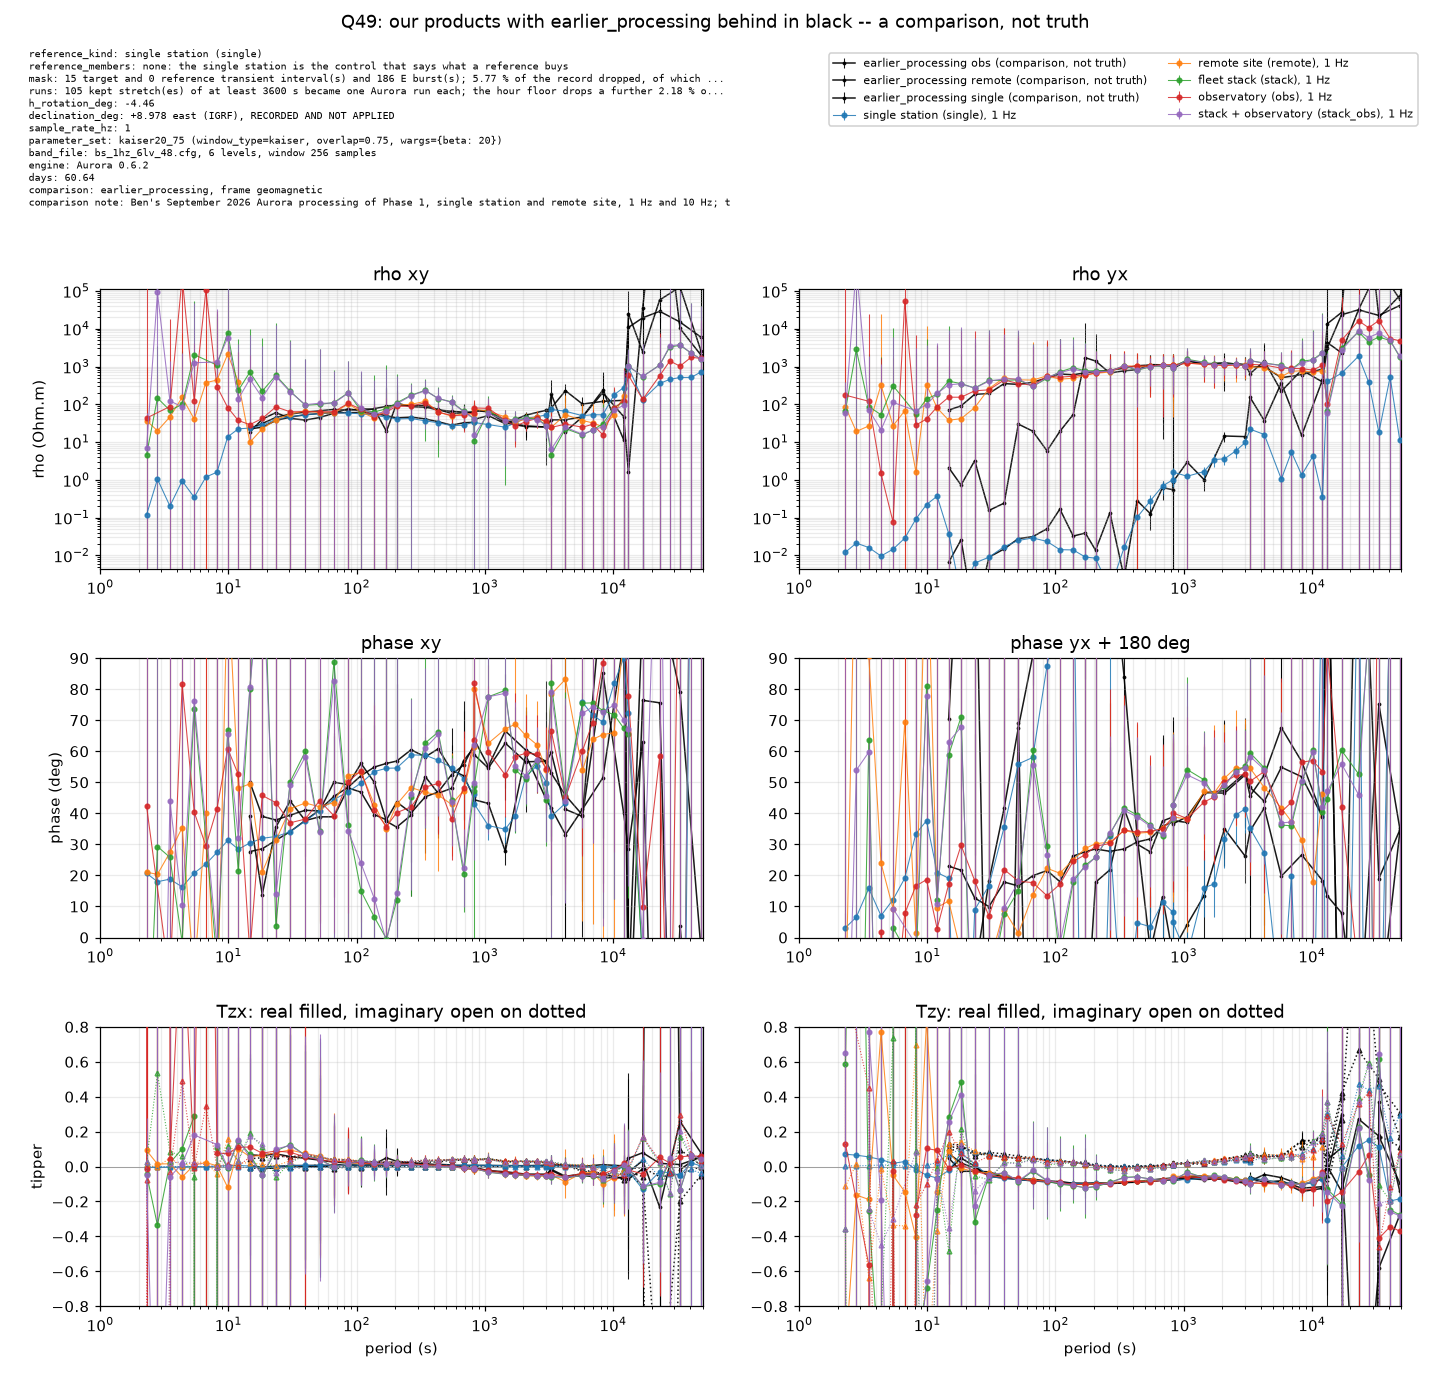

VERDICT: PASS -- all 2 declared source(s) carry a frame and a note (earlier_processing geomagnetic, campaign_merged geomagnetic), and the frame turn leaves every one of the 114 rotation invariants tested unchanged to better than 1e-9 relative


In [12]:
vs_pages = []
for src in SOURCES:
    if src["error"]:
        continue
    for site in CHOSEN:
        dec = DECLINATION.get(site)
        try:
            loaded = PR.load_comparison(src, site, dec)
        except Exception:
            loaded = {}
        if not loaded:
            continue
        comps = [("%s %s" % (src["name"], k or "site"), tf) for k, tf in sorted(loaded.items())]
        grp = PROD[PROD.site == site]
        on = grp[grp.on_disk]
        head = PR.metadata_lines(read(on.iloc[0].path).meta) if len(on) else []
        head = head + ["comparison: %s, frame %s%s" % (src["name"], src["frame"],
                                                       "" if src["rho_factor"] == 1.0 else
                                                       ", rho x %.2f" % src["rho_factor"]),
                       "comparison note: %s" % src["note"][:100]]
        path, _index = FIG.site_page(
            site, grp, read, WORK / site / ("products_%s_vs_%s.png" % (RUN_TAG, src["name"])),
            comparisons=comps, header_lines=head, period_range=PERIOD_RANGE,
            title="%s: our products with %s behind in black -- a comparison, not truth" % (site, src["name"]))
        vs_pages.append(path)
WRITTEN += vs_pages
print("%d page(s) redrawn with a source behind" % len(vs_pages))
if vs_pages:
    shown = [p for p in vs_pages if Path(p).parent.name == SHOW_SITE] or vs_pages
    display(Image(filename=str(shown[0])))

if not SOURCES:
    print("VERDICT: UNJUDGED -- survey.yaml declares no comparison source, or COMPARE is \"none\"")
elif no_frame or turn_bad:
    print("VERDICT: FAIL -- %d declared source(s) carry no frame or no note (%s); %d of %d rotation "
          "invariants move by more than 1e-9 relative (%s)"
          % (len(no_frame), "; ".join(no_frame) or "none", len(turn_bad), turn_n,
             "; ".join(turn_bad[:4]) or "none"))
elif not turn_n:
    print("VERDICT: UNJUDGED -- no comparison tensor was found to test the frame turn on")
else:
    print("VERDICT: PASS -- all %d declared source(s) carry a frame and a note (%s), and the frame turn "
          "leaves every one of the %d rotation invariants tested unchanged to better than 1e-9 relative"
          % (len(SOURCES), ", ".join("%s %s" % (s["name"], s["frame"]) for s in SOURCES), turn_n))


## The gallery

PER_PAGE sites a page, every product of the run, rho and phase for xy and yx. The legend is on the first page
only, so the panels carry no repeated key. Each page is written to
`<work_root>/survey/gallery_<run>_p<k>.png` and every curve drawn is named in the index CSV beside them.

**This check fails if any chosen site has no page and no gallery panel.** The two are counted from the files
and the index rather than from the list of sites: a site page is scored by the file existing on disk, and a
gallery panel by at least one row in the index naming that site.

4 gallery page(s), 260 curve(s) drawn
page
1    6
2    6
3    6
4    5


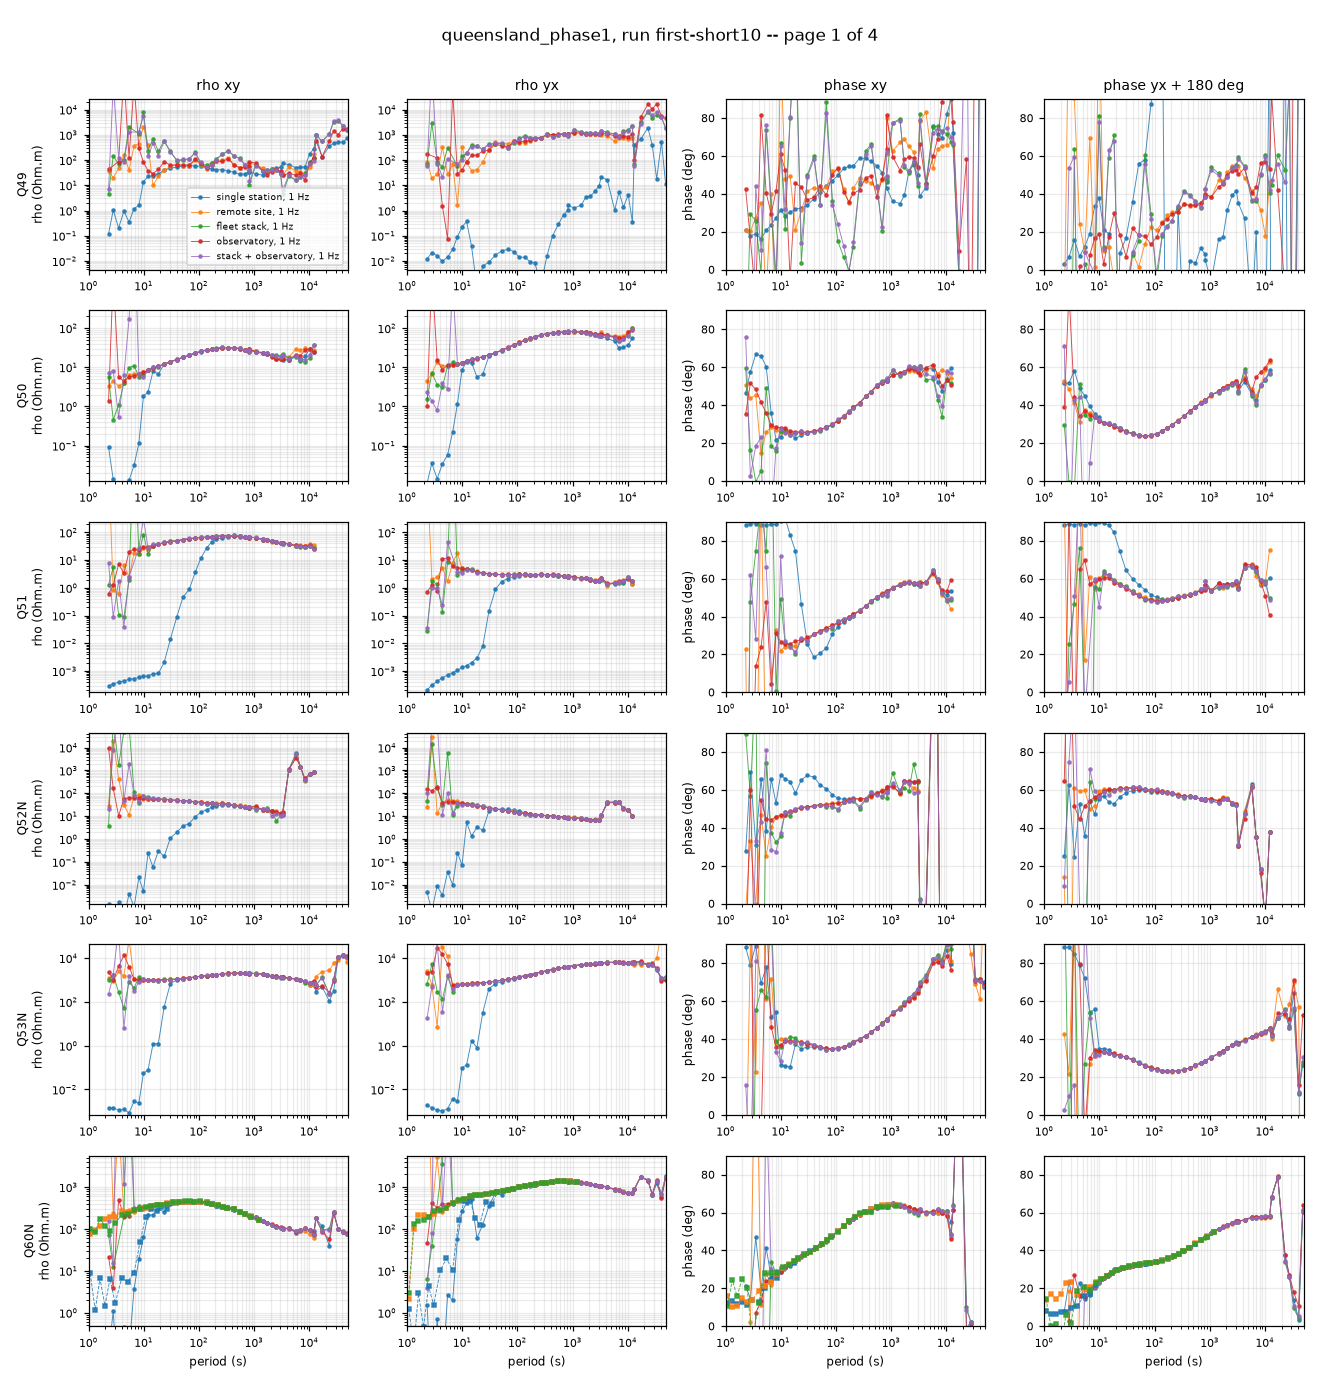

VERDICT: PASS -- all 23 chosen sites carry a page and at least one gallery panel; 260 curves on 4 gallery page(s) at 6 sites a page


In [13]:
pages, index, index_path = FIG.gallery(
    CHOSEN, PROD, read, OUT, stem="gallery_%s" % RUN_TAG, per_page=int(PER_PAGE),
    period_range=PERIOD_RANGE, title="%s, run %s" % (sv.cfg["name"], RUN_TAG))
WRITTEN += list(pages) + [index_path]
print("%d gallery page(s), %d curve(s) drawn" % (len(pages), len(index)))
print(index.groupby("page").site.nunique().to_string())
display(Image(filename=str(pages[0])))

no_page = [s for s in CHOSEN if not (WORK / s / ("products_%s.png" % RUN_TAG)).exists()]
no_panel = [s for s in CHOSEN if s not in set(index.site)] if len(index) else list(CHOSEN)
if not CHOSEN:
    print("VERDICT: UNJUDGED -- no site was chosen, so no page and no panel were drawn")
elif no_page or no_panel:
    print("VERDICT: FAIL -- %d of %d chosen sites have no page (%s) and %d have no gallery panel (%s)"
          % (len(no_page), len(CHOSEN), " ".join(no_page) or "none", len(no_panel),
             " ".join(no_panel) or "none"))
else:
    print("VERDICT: PASS -- all %d chosen sites carry a page and at least one gallery panel; %d curves on "
          "%d gallery page(s) at %d sites a page"
          % (len(CHOSEN), len(index), len(pages), int(PER_PAGE)))


## What was written

In [14]:
rows = []
for p in WRITTEN:
    p = Path(p)
    if p.exists():
        rows.append(dict(file=str(p), kb=round(p.stat().st_size / 1024, 1)))
files = pd.DataFrame(rows).drop_duplicates("file").sort_values("file")
print("%d files, %.1f MB, in %.1f minutes" % (len(files), files.kb.sum() / 1024, (time.time() - T0) / 60))
print(files.head(60).to_string(index=False))
if len(files) > 60:
    print("   ... and %d more" % (len(files) - 60))


59 files, 26.1 MB, in 0.8 minutes
                                                                                                           file    kb
                       E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\Q49\products_first-short10.png 577.6
    E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\Q49\products_first-short10_vs_campaign_merged.png 605.5
 E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\Q49\products_first-short10_vs_earlier_processing.png 681.1
                       E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\Q50\products_first-short10.png 340.9
    E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\Q50\products_first-short10_vs_campaign_merged.png 359.8
 E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\Q50\products_first-short10_vs_earlier_processing.png 432.4
                       E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\Q51\products_first-short10.png 425.2
    E:\MT_Timeseries_D